# Découvrez l'apprentissage d'ensemble avec les forêts aléatoires

Pour finir ce cours nous allons travailler sur l'apprentissage d'ensemble ou ensemble learning.

L'apprentissage d'ensemble consiste à combiner plusieurs modèles sous-optimisés pour construire un modèle global performant, stable, robuste.Ce principe est applicable à de nombreux types de modèles, mais c'est surtout avec les arbres de décision qu'on va le rencontrer.

Dans la pratique, l'apprentissage d'ensemble permet de réduire le biais et l'overfit d'un modèle et de lui apporter robustesse et stabilité face aux outliers et au bruit.

On considère 2 techniques :

- Le bagging qui, appliqué aux arbres de décision, donne naissance au modèle de forêt aléatoire.

- Le boosting qui engendre la famille des XGBoost.

## Découvrez le principe du bagging et des forêts aléatoires

Le bagging consiste à entraîner de multiples instances d'un modèle dont les performances sont par construction faibles. On appelle ce modèle de base un weak learner (ou prédicteur faible). Par exemple : un arbre de décision fortement contraint en profondeur.

On entraîne de nombreuses instances de ces prédicteurs faibles. Chaque instance est entraînée sur une partie des données d'entraînement et sur une partie des variables prédictives.

On combine ensuite les prédictions des prédicteurs faibles pour former le modèle d'ensemble.

- Pour la régression : la moyenne des prédictions des prédicteurs faibles.

- Pour la classification : le vote. La catégorie prédite par l'ensemble correspond à la catégorie la plus souvent prédite par les prédicteurs faibles.

Scikit-learn offre des forêts aléatoires pour la classification `RandomForestClassifier` et la régression `RandomForestRegressor`. Le prédicteur faible est un arbre de décision.

On retrouve dans ces 2 modèles les paramètres d'un arbre de décision, (tels que   max_depth  …) auxquels s'ajoutent les paramètres spécifiques à l'apprentissage d'ensemble :

- n_estimators  : le nombre d'arbres dans la forêt ;

- max_features  : le nombre de variables considérées pour chaque arbre ;

- bootstrap  : indique si chaque arbre est entraîné sur l'intégralité du jeu de données ou une partie échantillonnée.

### Bagging avec le dataset Hastie

In [5]:
from sklearn.datasets import make_hastie_10_2

X,y = make_hastie_10_2(n_samples=12000,random_state=8)

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


tree_counts = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=808)

accuracy=[]

for n_estimator in tree_counts:
    clf = RandomForestClassifier(n_estimators=n_estimator,max_depth=2,random_state=8)
    clf.fit(X_train,y_train)
    accuracy.append(clf.score(X_test,y_test))

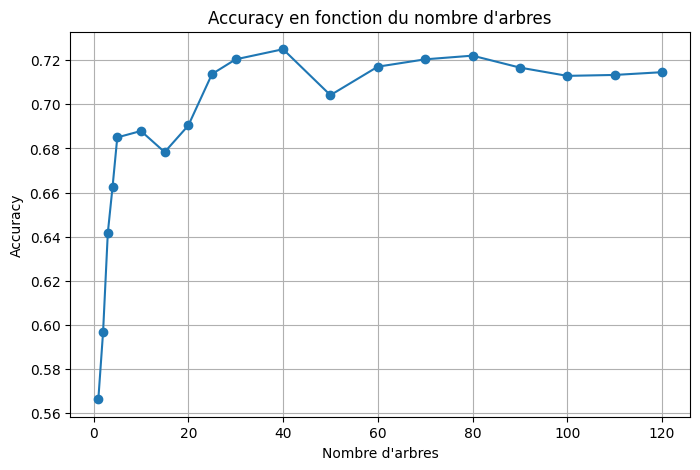

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(tree_counts, accuracy, marker='o')
plt.xlabel("Nombre d'arbres")
plt.ylabel("Accuracy")
plt.title("Accuracy en fonction du nombre d'arbres")
plt.grid(True)
plt.show()

## Réduisez la variance

Le bagging permet aussi de réduire l'overfit d'un modèle.
Donc la forêt aléatoire est un modèle fantastique pour réduire l'overfit de multiples façons :

- augmenter le nombre d'arbres ;

- contraindre l'arbre de base en réduisant  max_depth  ;

- réduire le nombre de variables sur lesquelles chaque arbre de base est entraîné.

## Estimez l’importance de chaque variable
Comme chaque arbre n'est pas entraîné sur toutes les variables, il est possible d'estimer l'importance de chaque variable.


In [8]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split


# chargement des données

filename = "https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/paris-arbres-numerical-2023-09-10.csv"
data = pd.read_csv(filename)

# X la matrice des prédicteurs
X = data[
    [
        "domanialite",
        "arrondissement",
        "libelle_francais",
        "genre",
        "espece",
        "circonference_cm",
        "hauteur_m",
    ]
]

# y la matrice de la variable cible
y = data.stade_de_developpement.values

# separation des données en train et en test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=808
)

In [9]:
clf = RandomForestClassifier(n_estimators=100, random_state=8)

clf.fit(X_train, y_train)

print(clf.feature_importances_)

[0.0388565  0.16102324 0.04076572 0.03633334 0.05559153 0.46194169
 0.20548799]


<Axes: >

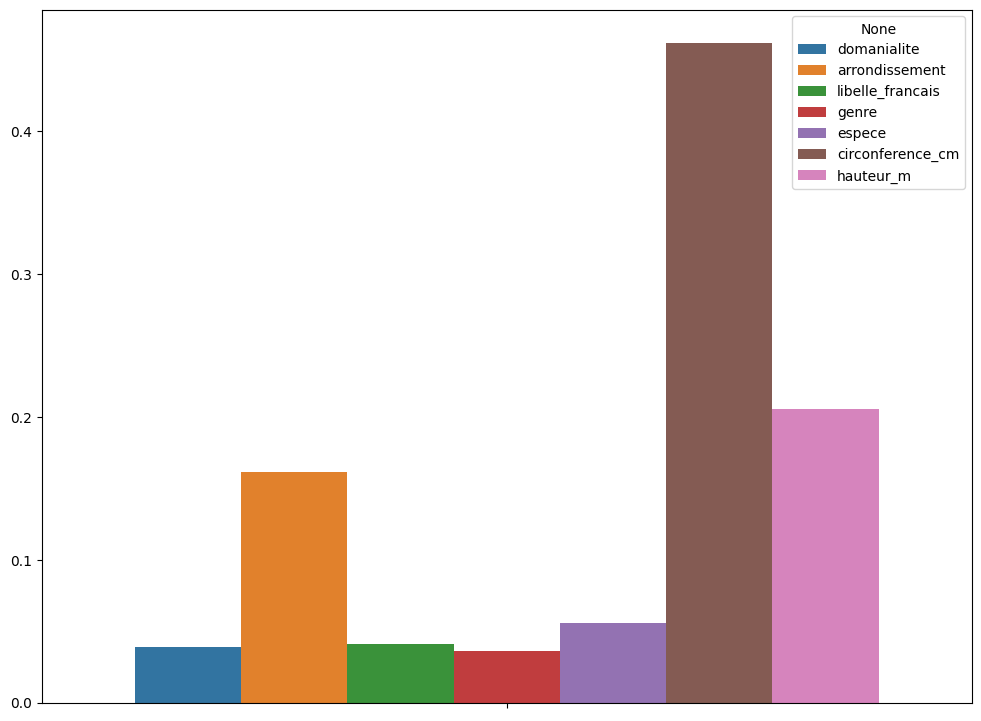

In [10]:
import seaborn as sns
plt.figure(figsize=(12,9))
sns.barplot(hue=X.columns,y=clf.feature_importances_)

La variable principale est la circonférence suivie par la largeur. L'arrondissement est aussi important.

## Découvrez le principe du boosting appliqué aux arbres de décision

Le modèle de forêt aléatoire est intrinsèquement parallèle. Les arbres sont entraînés en même temps sur des parties du dataset.

Le boosting, lui, enchaîne l'entraînement des prédicteurs fiables de façon séquentielle, en se concentrant à chaque itération sur les échantillons qui ont généré le plus d'erreurs.

Appliqué aux arbres de décision, le boosting donne naissance à XGBoost qui veut dire Extrême Gradient Boosting. C'est la progéniture d'une forêt aléatoire avec un gradient stochastique.

XGBoost existe en tant que librairie à part entière et a ensuite été intégré dans scikit-learn avec les modèles GradientBoostingClassifier et GradientBoostingRegressor. Il existe d'autres variantes de XGBoost appelées LightGBM et CatBoost.

Toutes ces librairies implémentent des versions légèrement différentes de XGBoost et se distinguent par :

- leur rapidité d'entraînement ;

- l'optimisation de la mémoire de l'ordinateur ;

- la constitution des ensembles d'arbres ;

- le traitement des variables catégoriques ;

- le nom et la signification des paramètres.

Nous allons utiliser la version scikit-learn du XGBoost pour la classification : GradientBoostingClassifier.

Il nous faut prendre en compte un nouveau paramètre qui provient de la partie gradient du  GradientBoosting  : le  learning_rate  ou taux d'apprentissage qui dicte la quantité de corrections prises en compte à chaque itération.

### Sélectionnez les paramètres d'un Gradient Boosting

Une bonne stratégie consiste à optimiser en premier lieu le nombre d'arbres :

1. Fixez   max_depth  à  3  , et le learning-rate à  0.

2. Optimisez le nombre d'arbres en faisant un  grid search  avec validation croisée sur différentes valeurs. Par exemple : 10, 50, 100, 200, 500.

3. Une fois le nombre d'arbres optimal trouvé, optimisez le  learning rate  . Pour optimiser le  learning rate  , gardez en tête que :

    - un  learning rate  élevé fait converger l'algorithme rapidement au détriment de l'erreur ;

    - en réduisant le  learning rate  , vous allez ralentir la convergence de l'algorithme mais en même temps réduire l'erreur jusqu'à atteindre un plateau.


### Réduisez la variance
Reprenons le dataset de Hastie et comparons la performance du modèle en fonction des valeurs décroissantes du  learning rate

In [11]:
X, y = make_hastie_10_2(n_samples=12000, random_state=8)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=808
)

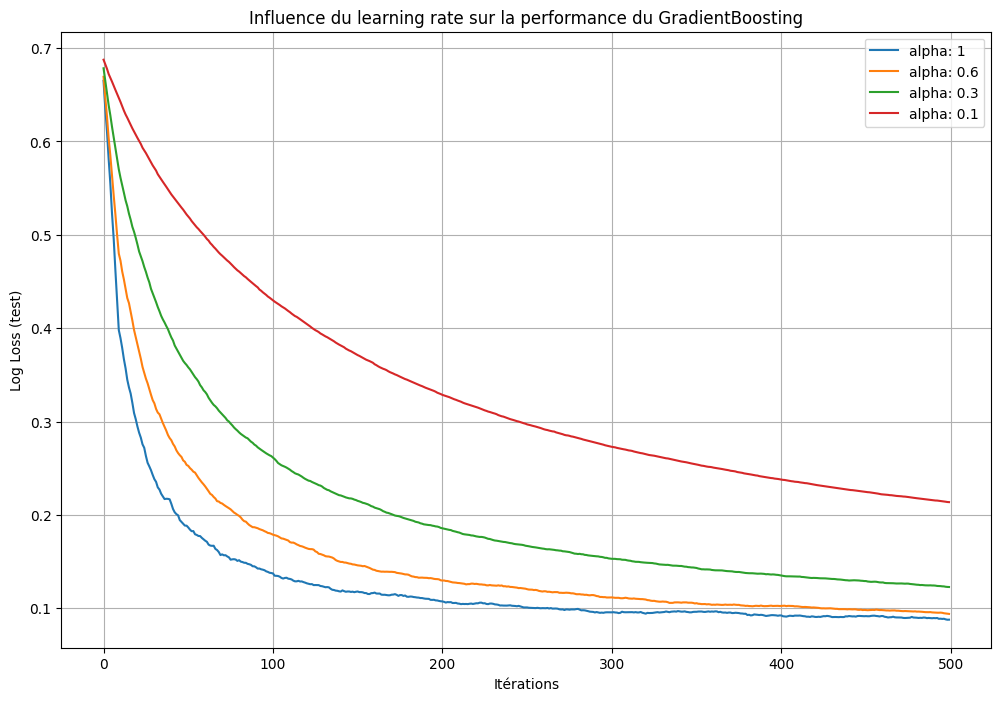

In [12]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss

learning_rates = [1, 0.6, 0.3, 0.1]

plt.figure(figsize=(12, 8))

for lr in learning_rates:
    clf = GradientBoostingClassifier(
        n_estimators=500, max_depth=2, random_state=8, learning_rate=lr
    )
    clf.fit(X_train, y_train)

    scores = np.zeros(clf.n_estimators_, dtype=np.float64)
    for i, y_proba in enumerate(clf.staged_predict_proba(X_test)):
        scores[i] = log_loss(y_test, y_proba[:, 1])

    plt.plot(scores, label=f"alpha: {lr}")

plt.title("Influence du learning rate sur la performance du GradientBoosting")
plt.xlabel("Itérations")
plt.ylabel("Log Loss (test)")
plt.legend()
plt.grid(True)
plt.show()

## Choisissez le bon modèle parmi tous les modèles de scikit-learn

Pour finir, un mot sur le choix du modèle lorsque l'on débute sur un nouveau problème et un nouveau dataset. Avec scikit-learn vous avez l'embarras du choix, et il peut sembler difficile de sélectionner le bon modèle.

Une stratégie simple consiste à commencer par une régression linéaire / logistique pour comprendre les dynamiques entre les variables de prédiction et la variable cible. Cela vous permettra de sélectionner les meilleures variables prédictives et d'obtenir un benchmark des performances attendues.